## EDA Berorientasi Bisnis (Analisis Diagnostik Operasional)
Bagian ini fokus membaca pola biaya logistik, subsidi ongkir, dan risiko pembatalan untuk menemukan titik inefisiensi yang paling berdampak ke biaya operasional.

Pertanyaan yang dijawab:
- Bagaimana karakter biaya pengiriman pada transaksi berbayar?
- Seberapa dominan kebijakan gratis ongkir di keseluruhan transaksi?
- Apakah transaksi gratis ongkir berkaitan dengan tingkat pembatalan yang lebih tinggi?


In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
from pathlib import Path

sns.set_theme(style="whitegrid")

base = Path("/Users/a/Documents/operasional_ecommers_indo/data/process")
print("Folder data ditemukan:", base.exists())
print("Daftar file di folder proses:", [p.name for p in base.glob("*.csv")])

df = pd.read_csv(base / "dataset_preprocessed_full.csv")
df_paid = pd.read_csv(base / "dataset_preprocessed_paid_shipping.csv")

print("Ukuran dataset penuh:", df.shape)
print("Ukuran dataset ongkir berbayar:", df_paid.shape)


Folder data ditemukan: True
Daftar file di folder proses: ['dataset_preprocessed_full.csv', 'dataset_preprocessed_paid_shipping.csv']
Ukuran dataset penuh: (20848, 22)
Ukuran dataset ongkir berbayar: (6296, 23)


### 1. Struktur Biaya Pengiriman
Bagian ini membaca pola biaya pada `df_paid` (transaksi yang benar-benar membayar ongkir) agar metrik biaya tidak bias oleh transaksi gratis ongkir.


#### a. Distribusi Ongkir Aktual

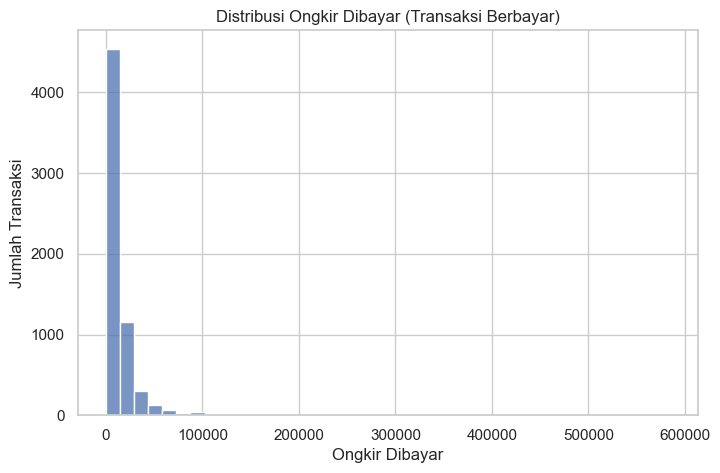

In [52]:
plt.figure(figsize=(8,5))
sns.histplot(df_paid["ongkir_dibayar"], bins=40)
plt.title("Distribusi Ongkir Dibayar (Transaksi Berbayar)")
plt.xlabel("Ongkir Dibayar")
plt.ylabel("Jumlah Transaksi")
plt.show()


**Interpretasi**
Histogram menunjukkan ongkir dibayar terkonsentrasi di rentang rendah dengan ekor panjang ke kanan. Artinya, sebagian besar transaksi berbayar punya ongkir moderat, tetapi ada sebagian kecil transaksi dengan ongkir sangat tinggi yang berpotensi menarik rata-rata naik.


#### b. Distribusi Ongkir per Kilogram (Clipped)

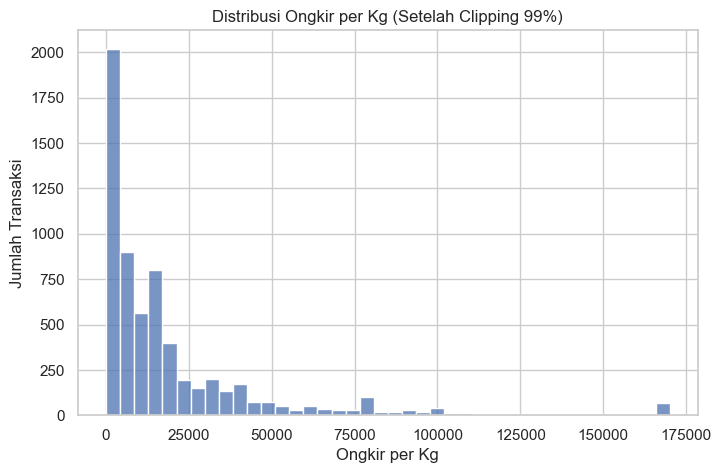

In [53]:
plt.figure(figsize=(8,5))
sns.histplot(df_paid["ongkir_per_kg_clipped"], bins=40)
plt.title("Distribusi Ongkir per Kg (Setelah Clipping 99%)")
plt.xlabel("Ongkir per Kg")
plt.ylabel("Jumlah Transaksi")
plt.show()


In [54]:

df_paid["ongkir_per_kg_clipped"].describe()

count      6296.000000
mean      20114.545645
std       28917.210029
min           0.227273
25%        3137.254902
50%       10000.000000
75%       22500.000000
max      170093.750000
Name: ongkir_per_kg_clipped, dtype: float64

**Interpretasi**
Dari output `describe()`, median ongkir per kg adalah **Rp 10.000**, kuartil 75% sekitar **Rp 22.500**, rata-rata **Rp 20.114**, dan nilai maksimum (setelah clipping) **Rp 170.093,75**. Ini menegaskan biaya per kg antar transaksi masih sangat bervariasi, sehingga analisis per segmen wilayah tetap penting.


#### c. Hubungan Berat dan Ongkir

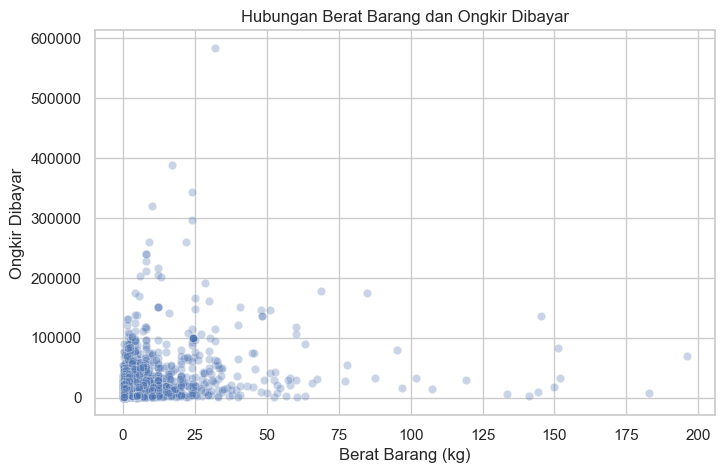

In [55]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x=df_paid["total_berat_kg"],
    y=df_paid["ongkir_dibayar"],
    alpha=0.3
)
plt.title("Hubungan Berat Barang dan Ongkir Dibayar")
plt.xlabel("Berat Barang (kg)")
plt.ylabel("Ongkir Dibayar")
plt.show()


**Interpretasi**
Scatter plot memperlihatkan pola naik: makin berat barang, ongkir cenderung makin tinggi. Namun titiknya tetap menyebar, jadi biaya tidak hanya dipengaruhi berat, tapi kemungkinan juga oleh zona pengiriman, tarif minimum, atau aturan kurir per wilayah.


#### d. Perbandingan Ongkir per Kg antar Provinsi (Top 10)

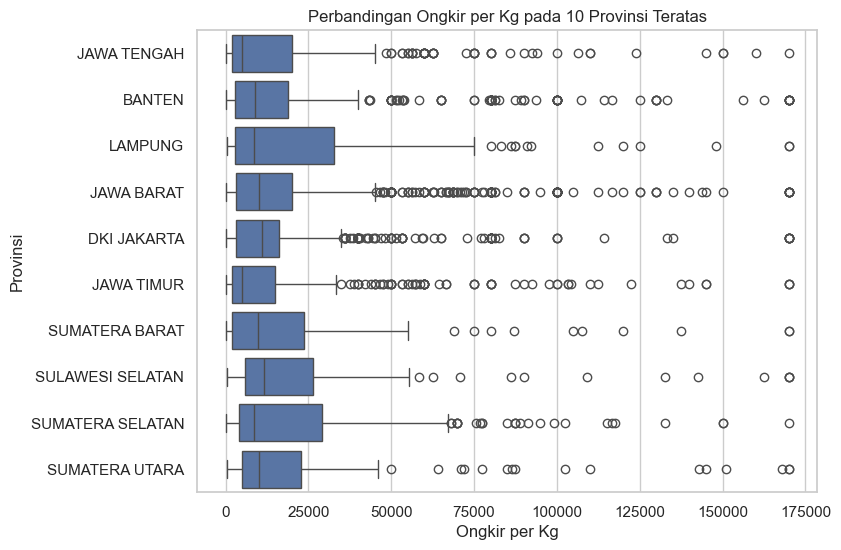

In [56]:
top_prov = df_paid["provinsi"].value_counts().head(10).index

plt.figure(figsize=(8,6))
sns.boxplot(
    data=df_paid[df_paid["provinsi"].isin(top_prov)],
    x="ongkir_per_kg_clipped",
    y="provinsi"
)
plt.title("Perbandingan Ongkir per Kg pada 10 Provinsi Teratas")
plt.xlabel("Ongkir per Kg")
plt.ylabel("Provinsi")
plt.show()


**Interpretasi**
Perbandingan 10 provinsi teratas menunjukkan median dan rentang ongkir per kg yang berbeda-beda. Perbedaan ini mengindikasikan struktur biaya regional tidak seragam, sehingga strategi subsidi dan kontrol biaya sebaiknya dibedakan per wilayah.


### 2. Evaluasi Subsidi Pengiriman
Setelah struktur biaya dipetakan, tahap berikutnya adalah menilai skala gratis ongkir dan dampaknya terhadap profil transaksi serta risiko pembatalan.


#### a. Proporsi Transaksi Subsidi

In [57]:
df["free_shipping_flag"].value_counts(normalize=True)


free_shipping_flag
1    0.698005
0    0.301995
Name: proportion, dtype: float64

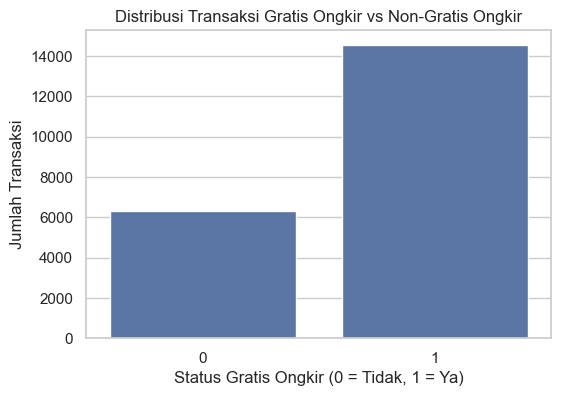

In [58]:
plt.figure(figsize=(6,4))
sns.countplot(x=df["free_shipping_flag"])
plt.title("Distribusi Transaksi Gratis Ongkir vs Non-Gratis Ongkir")
plt.xlabel("Status Gratis Ongkir (0 = Tidak, 1 = Ya)")
plt.ylabel("Jumlah Transaksi")
plt.show()


**Interpretasi**
Proporsi transaksi dengan gratis ongkir mencapai **69,80%**, sedangkan non-gratis ongkir **30,20%**. Karena mayoritas transaksi masuk kategori gratis ongkir, kebijakan ini sangat menentukan besar kecilnya beban biaya operasional.


#### b. Perbandingan Biaya Aktual: Gratis Ongkir vs Non-Gratis Ongkir


In [59]:
ringkasan_subsidi = df.groupby("free_shipping_flag").agg(
    rata_rata_ongkir=("ongkir_dibayar", "mean"),
    median_ongkir=("ongkir_dibayar", "median"),
    rata_rata_berat_kg=("total_berat_kg", "mean"),
    jumlah_transaksi=("ongkir_dibayar", "count")
)

ringkasan_subsidi


,rata_rata_ongkir,median_ongkir,rata_rata_berat_kg,jumlah_transaksi
free_shipping_flag,,,,
0,13874.352922,8000.0,3.073060,6296
1,0.000000,0.0,1.542225,14552


**Interpretasi**
Tabel ringkasan menunjukkan:
- Non-gratis ongkir (`0`): **6.296 transaksi**, rata-rata ongkir dibayar pelanggan sekitar **Rp 13.874**, rata-rata berat **3,07 kg**.
- Gratis ongkir (`1`): **14.552 transaksi**, ongkir dibayar pelanggan **Rp 0**, rata-rata berat **1,54 kg**.

Artinya, gratis ongkir lebih sering terjadi pada transaksi yang relatif lebih ringan.


#### c. Distribusi Ongkir Aktual pada Transaksi Gratis Ongkir


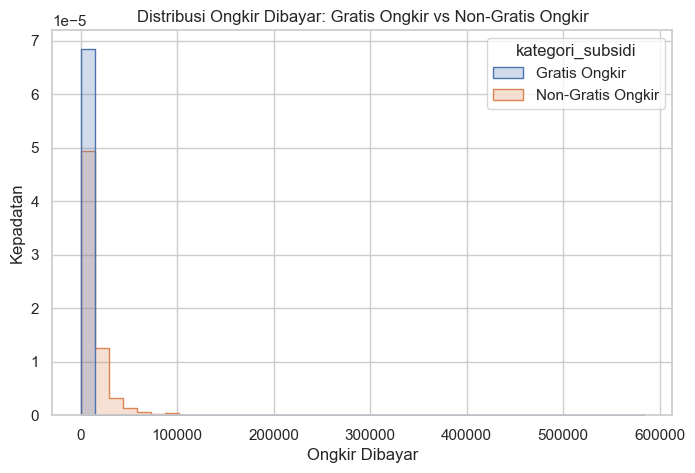

In [60]:
df_plot = df.copy()
df_plot["kategori_subsidi"] = np.where(
    df_plot["free_shipping_flag"] == 1,
    "Gratis Ongkir",
    "Non-Gratis Ongkir"
)

plt.figure(figsize=(8,5))
sns.histplot(
    data=df_plot,
    x="ongkir_dibayar",
    hue="kategori_subsidi",
    bins=40,
    element="step",
    stat="density",
    common_norm=False
)
plt.title("Distribusi Ongkir Dibayar: Gratis Ongkir vs Non-Gratis Ongkir")
plt.xlabel("Ongkir Dibayar")
plt.ylabel("Kepadatan")
plt.show()


**Interpretasi**
Distribusi dua kelompok terpisah jelas: transaksi gratis ongkir menumpuk di nilai 0, sedangkan non-gratis ongkir tersebar di nilai positif. Pemisahan ini penting agar evaluasi efisiensi ongkir tidak bias oleh transaksi promosi.


#### d. Subsidi dan Risiko Pembatalan

In [61]:
tingkat_batal = df.groupby("free_shipping_flag")["cancel_flag"].mean()
tingkat_batal


free_shipping_flag
0    0.000000
1    0.194475
Name: cancel_flag, dtype: float64

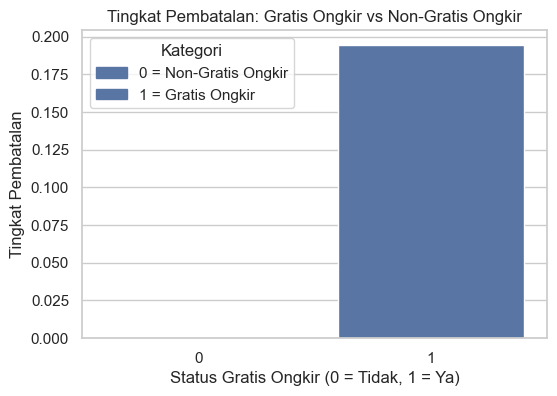

In [62]:
plt.figure(figsize=(6,4))
ax = sns.barplot(x=tingkat_batal.index, y=tingkat_batal.values)

plt.title("Tingkat Pembatalan: Gratis Ongkir vs Non-Gratis Ongkir")
plt.xlabel("Status Gratis Ongkir (0 = Tidak, 1 = Ya)")
plt.ylabel("Tingkat Pembatalan")

item_legenda = [
    mpatches.Patch(color=ax.patches[0].get_facecolor(), label="0 = Non-Gratis Ongkir"),
    mpatches.Patch(color=ax.patches[1].get_facecolor(), label="1 = Gratis Ongkir")
]
plt.legend(handles=item_legenda, title="Kategori", loc="best")

plt.show()


**Interpretasi**
Output `tingkat_batal` menunjukkan gap yang tajam:
- Non-gratis ongkir (`0`): **0,00%**
- Gratis ongkir (`1`): **19,45%**

Temuan ini menunjukkan transaksi gratis ongkir memiliki risiko pembatalan jauh lebih tinggi, sehingga program subsidi perlu ditargetkan lebih presisi.


### 3. Estimasi Beban Subsidi dan Simulasi Penghematan
Bagian ini mengubah temuan deskriptif menjadi estimasi finansial agar dampak kebijakan subsidi bisa dibaca dalam nilai rupiah.


#### a. Bangun Tarif Median per Provinsi

In [63]:
# Hitung median ongkir per kg per provinsi dari transaksi non-subsidi
median_tarif_prov = (
    df_paid.groupby("provinsi")["ongkir_per_kg"]
    .median()
    .reset_index()
    .rename(columns={"ongkir_per_kg": "median_tarif_per_kg"})
)
# Bulatkan ke ratusan rupiah agar lebih representatif secara bisnis
median_tarif_prov["median_tarif_per_kg"] = (
    (median_tarif_prov["median_tarif_per_kg"] / 100).round(0) * 100
)
median_tarif_prov.head()


,provinsi,median_tarif_per_kg
0,BALI,9200.0
1,BANGKA BELITUNG,13500.0
2,BANTEN,9000.0
3,BENGKULU,13800.0
4,DI YOGYAKARTA,4000.0


**Interpretasi**
Tarif median per provinsi dibangun dari transaksi berbayar sebagai acuan biaya yang lebih realistis. Dengan pendekatan ini, estimasi subsidi tidak terlalu dipengaruhi outlier ekstrem.


#### b. Estimasi Biaya Logistik untuk Transaksi Subsidi

In [64]:
# Ambil transaksi subsidi
df_sub = df[df["free_shipping_flag"] == 1].copy()

# Merge dengan median tarif provinsi
df_sub = df_sub.merge(median_tarif_prov, on="provinsi", how="left")

# Estimasi biaya logistik
df_sub["estimated_shipping_cost"] = (
    df_sub["total_berat_kg"] * df_sub["median_tarif_per_kg"]
)

df_sub[["provinsi", "total_berat_kg", "median_tarif_per_kg", "estimated_shipping_cost"]].head()


,provinsi,total_berat_kg,median_tarif_per_kg,estimated_shipping_cost
0,BANTEN,2.0,9000.0,18000.0
1,JAWA TENGAH,0.5,5000.0,2500.0
2,JAWA BARAT,0.5,10000.0,5000.0
3,JAMBI,0.4,13000.0,5200.0
4,BANTEN,3.6,9000.0,32400.0


**Interpretasi**
Estimasi biaya transaksi subsidi dihitung dari `total_berat_kg x median_tarif_per_kg` per provinsi. Cara ini sederhana, transparan, dan cukup kuat untuk simulasi kebijakan awal.


#### c. Estimasi Total Beban Subsidi

In [65]:
total_estimasi_subsidi = df_sub["estimated_shipping_cost"].sum()
rata_rata_estimasi_subsidi = df_sub["estimated_shipping_cost"].mean()
median_estimasi_subsidi = df_sub["estimated_shipping_cost"].median()

print(f"Perkiraan total beban subsidi: Rp {round(total_estimasi_subsidi, -3):,.0f}")
print(f"Rata-rata subsidi per transaksi: Rp {round(rata_rata_estimasi_subsidi, -2):,.0f}")
print(f"Median subsidi per transaksi: Rp {round(median_estimasi_subsidi, -2):,.0f}")


Perkiraan total beban subsidi: Rp 218,644,000
Rata-rata subsidi per transaksi: Rp 15,000
Median subsidi per transaksi: Rp 5,000


**Interpretasi**
Hasil estimasi menunjukkan:
- Perkiraan total beban subsidi: **Rp 218.644.000**
- Rata-rata subsidi per transaksi: **Rp 15.000**
- Median subsidi per transaksi: **Rp 5.000**

Rata-rata yang jauh di atas median menunjukkan ada sebagian transaksi berbiaya tinggi yang mendorong total subsidi naik secara signifikan.


#### d. Simulasi Penghematan (Subsidi Lebih Terarah)
Simulasi ini menguji skenario sederhana: subsidi hanya diberikan untuk transaksi dengan estimasi biaya di bawah atau sama dengan median.


In [66]:
ambang = median_estimasi_subsidi

simulasi_total = df_sub[
    df_sub["estimated_shipping_cost"] <= ambang
]["estimated_shipping_cost"].sum()

potensi_hemat = total_estimasi_subsidi - simulasi_total

print(f"Total subsidi jika hanya diberikan pada biaya <= median: Rp {round(simulasi_total, -3):,.0f}")
print(f"Potensi penghematan: Rp {round(potensi_hemat, -3):,.0f}")


Total subsidi jika hanya diberikan pada biaya <= median: Rp 22,705,000
Potensi penghematan: Rp 195,939,000


**Interpretasi**
Dalam simulasi ini, total subsidi turun menjadi **Rp 22.705.000** dan potensi penghematan mencapai **Rp 195.939.000**. Angkanya menunjukkan peluang efisiensi yang besar, tetapi implementasi kebijakan tetap perlu diuji terhadap dampak konversi dan kepuasan pelanggan.


### 4. Segmentasi Risiko Subsidi
Tahap ini memetakan transaksi subsidi ke dalam segmen biaya dan status pembatalan agar area prioritas perbaikan bisa terlihat lebih tajam.


#### a. Kategorisasi Biaya Subsidi
Gunakan median estimasi subsidi sebagai batas segmen:
- `Biaya Tinggi`: biaya di atas median
- `Biaya Rendah`: biaya di bawah atau sama dengan median


In [67]:
ambang_biaya = median_estimasi_subsidi

df_sub["cost_segment"] = df_sub["estimated_shipping_cost"].apply(
    lambda x: "Biaya Tinggi" if x > ambang_biaya else "Biaya Rendah"
)


#### b. Hitung Tingkat Pembatalan per Segmen Biaya


In [68]:
ringkasan_biaya_batal = (
    df_sub.groupby("cost_segment")
    .agg(
        jumlah_transaksi=("cancel_flag", "count"),
        tingkat_pembatalan=("cancel_flag", "mean"),
        rata_rata_biaya=("estimated_shipping_cost", "mean")
    )
)

ringkasan_biaya_batal


,jumlah_transaksi,tingkat_pembatalan,rata_rata_biaya
cost_segment,,,
Biaya Rendah,8176,0.152642,2777.023545
Biaya Tinggi,6376,0.248118,30730.700831


**Interpretasi**
Ringkasan segmen menunjukkan:
- `Biaya Tinggi`: **6.376 transaksi**, tingkat pembatalan **24,81%**, rata-rata biaya sekitar **Rp 30.731**.
- `Biaya Rendah`: **8.176 transaksi**, tingkat pembatalan **15,26%**, rata-rata biaya sekitar **Rp 2.777**.

Kombinasi biaya tinggi dan tingkat batal tinggi pada segmen `Biaya Tinggi` menandakan area ini paling potensial untuk efisiensi kebijakan subsidi.


#### c. Buat Matriks 2x2 (Biaya Tinggi/Rendah x Batal/Tidak Batal)
Matriks ini dipakai untuk melihat konsentrasi transaksi yang menyerap subsidi besar tetapi berakhir batal.


In [69]:
df_sub["cancel_segment"] = df_sub["cancel_flag"].apply(
    lambda x: "Batal" if x == 1 else "Tidak Batal"
)

matrix_summary = (
    df_sub.groupby(["cost_segment", "cancel_segment"])
    .size()
    .unstack()
)

matrix_summary


cancel_segment,Batal,Tidak Batal
cost_segment,,
Biaya Rendah,1248,6928
Biaya Tinggi,1582,4794


**Interpretasi**
Matriks memperlihatkan jumlah `Batal` pada segmen `Biaya Tinggi` (**1.582**) lebih tinggi dibanding `Biaya Rendah` (**1.248**), padahal jumlah transaksi `Biaya Tinggi` lebih kecil. Ini memperkuat sinyal bahwa subsidi berbiaya tinggi punya risiko pemborosan yang lebih besar.


#### d. Visualisasi Tingkat Pembatalan per Segmen


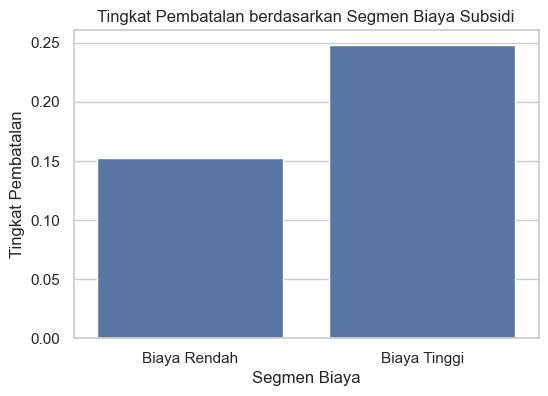

In [70]:
plt.figure(figsize=(6,4))
sns.barplot(
    data=ringkasan_biaya_batal.reset_index(),
    x="cost_segment",
    y="tingkat_pembatalan"
)
plt.title("Tingkat Pembatalan berdasarkan Segmen Biaya Subsidi")
plt.xlabel("Segmen Biaya")
plt.ylabel("Tingkat Pembatalan")
plt.show()


### Ringkasan Strategis
Dari seluruh analisis di notebook ini, tiga pesan utamanya:
- Gratis ongkir sangat dominan (hampir 70% transaksi), jadi dampaknya ke biaya total sangat besar.
- Segmen subsidi berbiaya tinggi memiliki tingkat pembatalan paling tinggi, sehingga menjadi prioritas evaluasi.
- Simulasi subsidi terarah menunjukkan potensi penghematan besar, namun perlu uji lanjutan agar tidak menurunkan performa penjualan.

----


## 5. Ekspor Dataset untuk Visualisasi Tableau
Pada tahap ini, dataset hasil olahan diekspor ke folder `../data/process` dalam tiga file terpisah:
1. Dataset transaksi subsidi (transaction-level)
2. Dataset struktur biaya non-subsidi
3. Dataset ringkasan provinsi (executive layer)


In [71]:
# Folder output
out_dir = Path("../data/process")
out_dir.mkdir(parents=True, exist_ok=True)

def siapkan_kolom_waktu(dataframe: pd.DataFrame) -> pd.DataFrame:
    df_tmp = dataframe.copy()

    kandidat = ["waktu_pesanan", "Waktu Pesanan Dibuat", "waktu_pesanan_dibuat"]
    kolom_waktu_asal = next((c for c in kandidat if c in df_tmp.columns), None)

    if kolom_waktu_asal is None:
        raise KeyError("Kolom waktu tidak ditemukan pada dataframe.")

    df_tmp["waktu_pesanan"] = pd.to_datetime(df_tmp[kolom_waktu_asal], errors="coerce")
    df_tmp["tahun"] = df_tmp["waktu_pesanan"].dt.year
    df_tmp["bulan"] = df_tmp["waktu_pesanan"].dt.month
    return df_tmp


### a. Persiapan Kolom Segmentasi
Pastikan `cost_segment` tersedia pada `df_sub` agar bisa dipakai untuk analisis risiko dan agregasi eksekutif.


In [72]:
if "cost_segment" not in df_sub.columns:
    ambang_biaya = df_sub["estimated_shipping_cost"].median()
    df_sub["cost_segment"] = np.where(
        df_sub["estimated_shipping_cost"] > ambang_biaya,
        "Biaya Tinggi",
        "Biaya Rendah"
    )

df_sub_export = siapkan_kolom_waktu(df_sub)
df_paid_export = siapkan_kolom_waktu(df_paid)


### b. Ekspor Dataset A - Transaksi Subsidi (Transaction-Level)
Dataset ini dipakai untuk overview subsidi dan segmentasi risiko pembatalan.


In [ ]:
kolom_subsidi = [
    "order_id",
    "waktu_pesanan",
    "tahun",
    "bulan",
    "provinsi",
    "total_berat_kg",
    "cancel_flag",
    "free_shipping_flag",
    "median_tarif_per_kg",
    "estimated_shipping_cost",
    "cost_segment",
]

dataset_subsidi = df_sub_export[kolom_subsidi].copy()

file_subsidi = out_dir / "ransaksi_subsidi.csv"
dataset_subsidi.to_csv(file_subsidi, index=False)

print(f"Berhasil: dataset transaksi subsidi tersimpan di {file_subsidi.resolve()}")


Berhasil: dataset transaksi subsidi tersimpan di /Users/a/Documents/operasional_ecommers_indo/data/process/tableau_transaksi_subsidi.csv


### c. Ekspor Dataset B - Struktur Biaya Non-Subsidi
Dataset ini dipakai untuk analisis distribusi ongkir dan struktur biaya logistik aktual.


In [74]:
kolom_biaya = [
    "order_id",
    "waktu_pesanan",
    "tahun",
    "bulan",
    "provinsi",
    "total_berat_kg",
    "ongkir_dibayar",
    "ongkir_per_kg",
    "ongkir_per_kg_clipped",
]

dataset_biaya = df_paid_export[kolom_biaya].copy()

file_biaya = out_dir / "tableau_struktur_biaya_non_subsidi.csv"
dataset_biaya.to_csv(file_biaya, index=False)

print(f"Berhasil: dataset struktur biaya non-subsidi tersimpan di {file_biaya.resolve()}")


Berhasil: dataset struktur biaya non-subsidi tersimpan di /Users/a/Documents/operasional_ecommers_indo/data/process/tableau_struktur_biaya_non_subsidi.csv


### d. Ekspor Dataset C - Ringkasan Provinsi (Executive Layer)
Dataset agregat per provinsi untuk kebutuhan dashboard manajerial.


In [75]:
ringkasan_provinsi = (
    df_sub_export.groupby("provinsi", as_index=False)
    .agg(
        jumlah_transaksi=("order_id", "count"),
        total_estimated_subsidy=("estimated_shipping_cost", "sum"),
        avg_estimated_subsidy=("estimated_shipping_cost", "mean"),
        cancel_rate=("cancel_flag", "mean"),
        high_cost_ratio=("cost_segment", lambda x: (x == "Biaya Tinggi").mean()),
    )
)

# Pembulatan business-ready
ringkasan_provinsi["total_estimated_subsidy"] = ringkasan_provinsi["total_estimated_subsidy"].round(0)
ringkasan_provinsi["avg_estimated_subsidy"] = ringkasan_provinsi["avg_estimated_subsidy"].round(0)
ringkasan_provinsi["cancel_rate"] = ringkasan_provinsi["cancel_rate"].round(4)
ringkasan_provinsi["high_cost_ratio"] = ringkasan_provinsi["high_cost_ratio"].round(4)

file_ringkasan = out_dir / "tableau_ringkasan_provinsi_subsidi.csv"
ringkasan_provinsi.to_csv(file_ringkasan, index=False)

print(f"Berhasil: dataset ringkasan provinsi tersimpan di {file_ringkasan.resolve()}")


Berhasil: dataset ringkasan provinsi tersimpan di /Users/a/Documents/operasional_ecommers_indo/data/process/tableau_ringkasan_provinsi_subsidi.csv


### e. Validasi Hasil Ekspor
Pastikan seluruh file sudah terbentuk sebelum lanjut ke Tableau.


In [76]:
print("Daftar file CSV di folder proses:")
for f in sorted(out_dir.glob("tableau_*.csv")):
    print("-", f.name)


Daftar file CSV di folder proses:
- tableau_ringkasan_provinsi_subsidi.csv
- tableau_struktur_biaya_non_subsidi.csv
- tableau_transaksi_subsidi.csv
